単語ベクトルモデルを読み込んでいます...
モデルの読み込み完了。
国名リストファイル 'Book1.csv' を読み込んでいます...
209個のユニークな国名をファイルから抽出しました。
  (情報) 'American Samoa' はモデルの語彙にないためスキップします。
  (情報) 'Antigua and Barbuda' はモデルの語彙にないためスキップします。
  (情報) 'Bolivia, Plurinational State of' はモデルの語彙にないためスキップします。
  (情報) 'Bosnia and Herzegovina' はモデルの語彙にないためスキップします。
  (情報) 'Brunei Darussalam' はモデルの語彙にないためスキップします。
  (情報) 'Burkina Faso' はモデルの語彙にないためスキップします。
  (情報) 'Cape Verde' はモデルの語彙にないためスキップします。
  (情報) 'Cayman Islands' はモデルの語彙にないためスキップします。
  (情報) 'Central African Republic' はモデルの語彙にないためスキップします。
  (情報) 'Costa Rica' はモデルの語彙にないためスキップします。
  (情報) 'Côte d'Ivoire' はモデルの語彙にないためスキップします。
  (情報) 'Dominican Republic' はモデルの語彙にないためスキップします。
  (情報) 'El Salvador' はモデルの語彙にないためスキップします。
  (情報) 'Eswatini' はモデルの語彙にないためスキップします。
  (情報) 'Faroe Islands' はモデルの語彙にないためスキップします。
  (情報) 'French Guiana' はモデルの語彙にないためスキップします。
  (情報) 'French Polynesia' はモデルの語彙にないためスキップします。
  (情報) 'Guinea-Bissau' はモデルの語彙にないためスキップします。
  (情報) 'Hong Kong' はモデルの語彙にないためスキップします。
  (情報) 'Iran, Islamic Republ

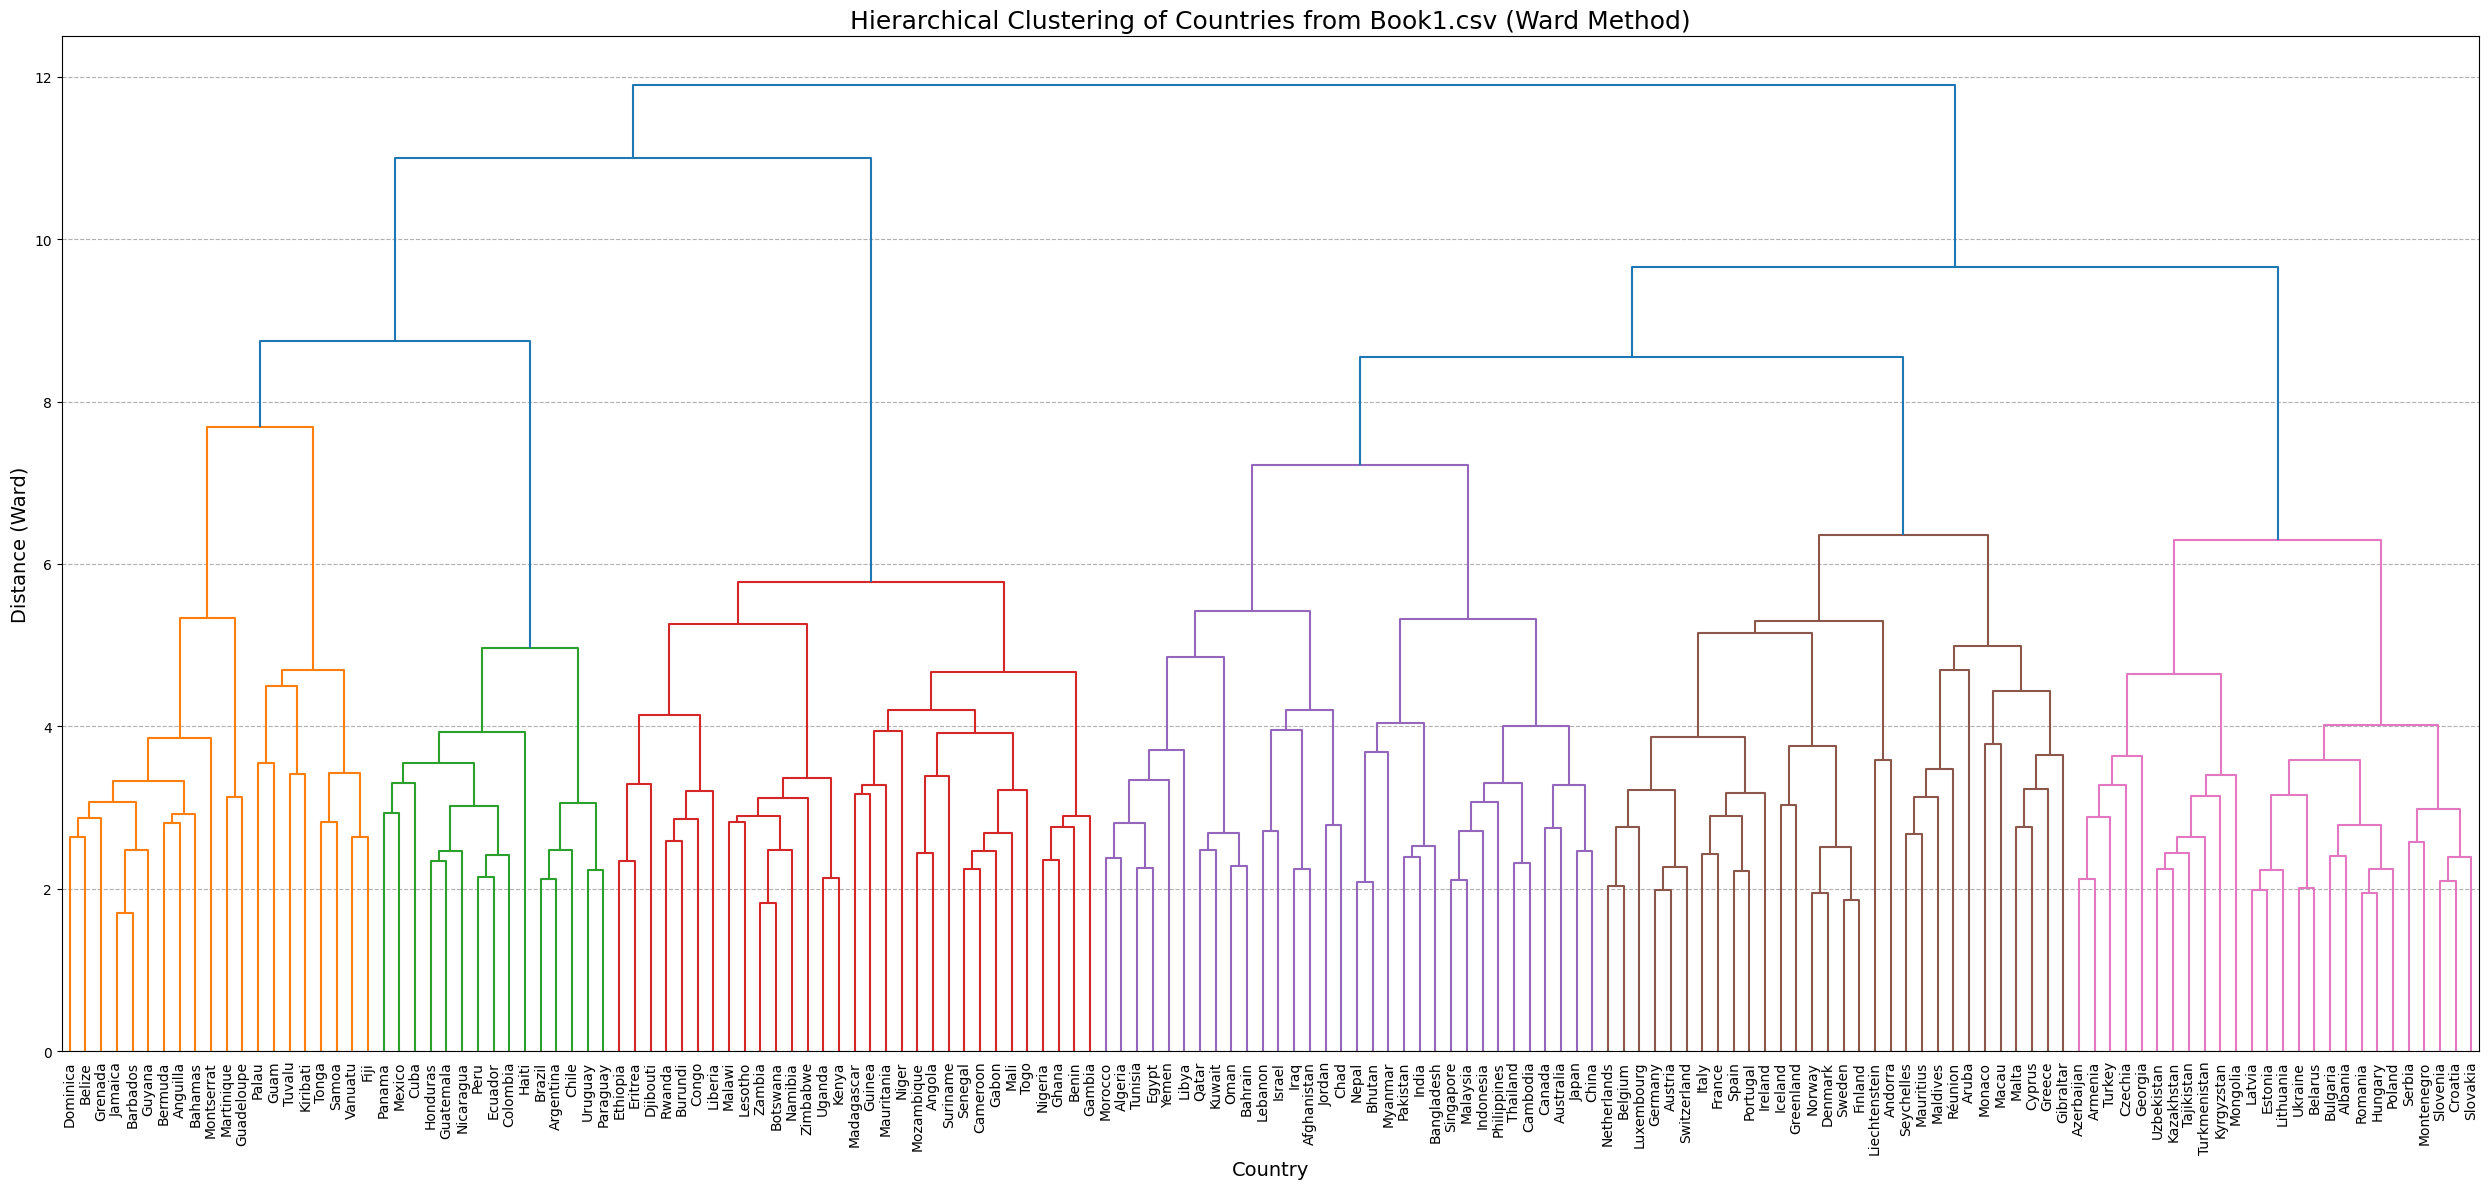

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import KeyedVectors
from scipy.cluster.hierarchy import linkage, dendrogram

# --- ファイルパスの設定 ---
MODEL_FILE = "GoogleNews-vectors-negative300.bin.gz"
COUNTRY_LIST_FILE = "Book1.csv"

# --- 必要なファイルの存在をチェック ---
if not os.path.exists(MODEL_FILE):
    print(f"エラー: モデルファイルが見つかりません: {MODEL_FILE}")
elif not os.path.exists(COUNTRY_LIST_FILE):
    print(f"エラー: 国名リストファイルが見つかりません: {COUNTRY_LIST_FILE}")
else:
    try:
        # 1. モデルの読み込み
        print("単語ベクトルモデルを読み込んでいます...")
        model = KeyedVectors.load_word2vec_format(MODEL_FILE, binary=True)
        print("モデルの読み込み完了。")

        # 2. 国名リストの抽出 (Book1.csvから)
        print(f"国名リストファイル '{COUNTRY_LIST_FILE}' を読み込んでいます...")
        df = pd.read_csv(COUNTRY_LIST_FILE, header=None, on_bad_lines='skip')
        # 1列目のデータを取得し、前後の空白を除去し、重複を削除
        country_names = df[0].str.strip().dropna().unique().tolist()
        print(f"{len(country_names)}個のユニークな国名をファイルから抽出しました。")

        # 3. モデルに存在する国名の単語ベクトルを抽出
        country_vectors = []
        valid_country_names = []
        for country in sorted(country_names): # 順序を固定するためソート
            if country in model:
                country_vectors.append(model[country])
                valid_country_names.append(country)
            else:
                print(f"  (情報) '{country}' はモデルの語彙にないためスキップします。")
        
        # scikit-learnで扱えるようにNumpy配列に変換
        X = np.array(country_vectors)
        print(f"\nモデルの語彙に存在する{len(valid_country_names)}個の国名ベクトルを抽出しました。")

        # クラスタリングを実行するのに十分なデータがあるかチェック
        if len(valid_country_names) < 2:
            print("エラー: クラスタリングを実行するには有効な国が2カ国以上必要です。")
        else:
            # 4. Ward法による階層型クラスタリングの実行
            print("Ward法による階層型クラスタリングを実行中...")
            # linkage関数がクラスタリングを計算し、その結果（リンケージ行列）を返す
            linked = linkage(X, method='ward')
            print("クラスタリング完了。")

            # 5. デンドログラムとして可視化
            print("デンドログラムを生成しています...")
            plt.figure(figsize=(25, 12))  # プロットのサイズを大きめに設定

            dendrogram(
                linked,
                orientation='top',
                labels=valid_country_names, # 各要素のラベルに国名を設定
                distance_sort='descending',
                leaf_rotation=90,  # ラベルを90度回転させて見やすくする
                leaf_font_size=10,  # ラベルのフォントサイズを調整
            )

            plt.title(f'Hierarchical Clustering of Countries from {COUNTRY_LIST_FILE} (Ward Method)', fontsize=18)
            plt.ylabel('Distance (Ward)', fontsize=14)
            plt.xlabel('Country', fontsize=14)
            plt.grid(axis='y', linestyle='--')
            plt.tight_layout() # レイアウトを自動調整
            print("プロットウィンドウを表示します。閉じるまで処理は待機します。")
            plt.show()

    except Exception as e:
        print(f"処理中に予期せぬエラーが発生しました: {e}")